# ArchR on subset of data

In [1]:
here::i_am("blood_trajectory/manual_iterativeLSI.ipynb")

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(uwot))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(parallel))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
args <- list()
args$seed = 1234
# in vivo
io$atlas.basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'
args$sce_atlas <-file.path(io$atlas.basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
args$metadataRNA_atlas <- file.path(io$atlas.basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$metadataATAC_atlas <- file.path(io$atlas.basedir, '/results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$celltype_label <- "celltype"

args$sample <- c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')

# LSI
args$ntop = 45000
args$ndims = 25

# Trajectory 
opts$celltypes = c("Epiblast",
                    "Primitive_Streak" ,
                    "Nascent_mesoderm",
                    "ExE_mesoderm",
                    "Mixed_mesoderm",
                    "Allantois",
                    "Mesenchyme",
                    "Haematoendothelial_progenitors",
                    "Endothelium",
                    "Blood_progenitors_1",
                    "Blood_progenitors_2",
                    "Erythroid1",
                    "Erythroid2",
                    "Erythroid3")

# I/O
args$outdir = file.path(io$basedir, 'results/epiblast_blood/atac/')
dir.create(args$outdir, showWarnings=F, recursive=T)

In [3]:
##########################
## Load sample metadata ##
##########################

metadata_atlas <- fread(args$metadataRNA_atlas) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>%
    merge(.,fread(args$metadataATAC_atlas)[,c('cell', 'pass_atacQC')], by='cell') %>%
    .[pass_atacQC==TRUE]

stopifnot(args$celltype_label%in%colnames(metadata_atlas))
metadata_atlas <- metadata_atlas   %>%
  .[,celltype:=eval(as.name(args$celltype_label))] %>%
  .[celltype%in%opts$celltypes] %>%
  .[,celltype:=factor(celltype,levels=opts$celltypes)] %>%
  .[sample%in% args$sample]

table(metadata_atlas$celltype)


                      Epiblast               Primitive_Streak 
                           984                            542 
              Nascent_mesoderm                   ExE_mesoderm 
                          1327                           1173 
                Mixed_mesoderm                      Allantois 
                           265                            653 
                    Mesenchyme Haematoendothelial_progenitors 
                          3123                            913 
                   Endothelium            Blood_progenitors_1 
                           666                            230 
           Blood_progenitors_2                     Erythroid1 
                           565                           1119 
                    Erythroid2                     Erythroid3 
                           939                            187 

In [4]:
########################
## Load ArchR Project ##
########################
io$archR.directory = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR'
addArchRVerbose(FALSE)
addArchRThreads(16)
proj = loadArchRProject(io$archR.directory)

Setting addArchRVerbose = FALSE

Setting default number of Parallel threads to 16.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\_

In [5]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR 
samples(11): E7.5_rep1 E7.5_rep2 ... E8.5_CRISPR_T_KO E8.5_CRISPR_T_WT
sampleColData names(1): ArrowFiles
cellColData names(35): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 89137
medianTSS(1): 16.382
medianFrags(1): 22077

In [6]:
#######################
## Subset proj & LSI ##
#######################
proj <- proj[metadata_atlas$cell]

proj <- addIterativeLSI(
    ArchRProj = proj,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = args$ntop, 
    dimsToUse = 1:args$ndims
)

Checking Inputs...

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [54]:
LSI = getReducedDims(ArchRProj = proj, reducedDims = "IterativeLSI",)

Filtering 1 dims correlated > 0.75 to log10(depth + 1)



In [82]:
fwrite(as.data.table(LSI, keep.rownames=T) %>% setnames('rn', 'cell') , sprintf("%s/LSI_ArchR.txt.gz",args$outdir))

In [12]:
get_umap = function(ndims = args$ndims, n_neighbors = 25, min_dist=0.3, plot=FALSE){
    # If ndims > dims in LSI, lower to dims in LSI
    if(ndims > dim(LSI)[2]){
        ndims = dim(LSI)[2]
    }
    
    # Calculate UMAP
    umap.mtx = umap(LSI[,1:ndims], 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table(keep.rownames=T) %>% setnames('rn', 'cell') %>% 
      setnames(c("cell", "UMAP1","UMAP2")) %>%
      merge(.,metadata_atlas[,c('cell', 'celltype', 'stage', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point() + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=stage)) + 
        geom_point() + 
        ggtitle('celltype') + 
        scale_colour_manual(values=opts$stage.colors) + 
        theme_void() + 
        theme(legend.position="none")
    
    options(repr.plot.width=20, repr.plot.height=6)
    
    if(plot==TRUE){ggarrange(p1, p2)}
    else{return(umap.dt)}
    
}

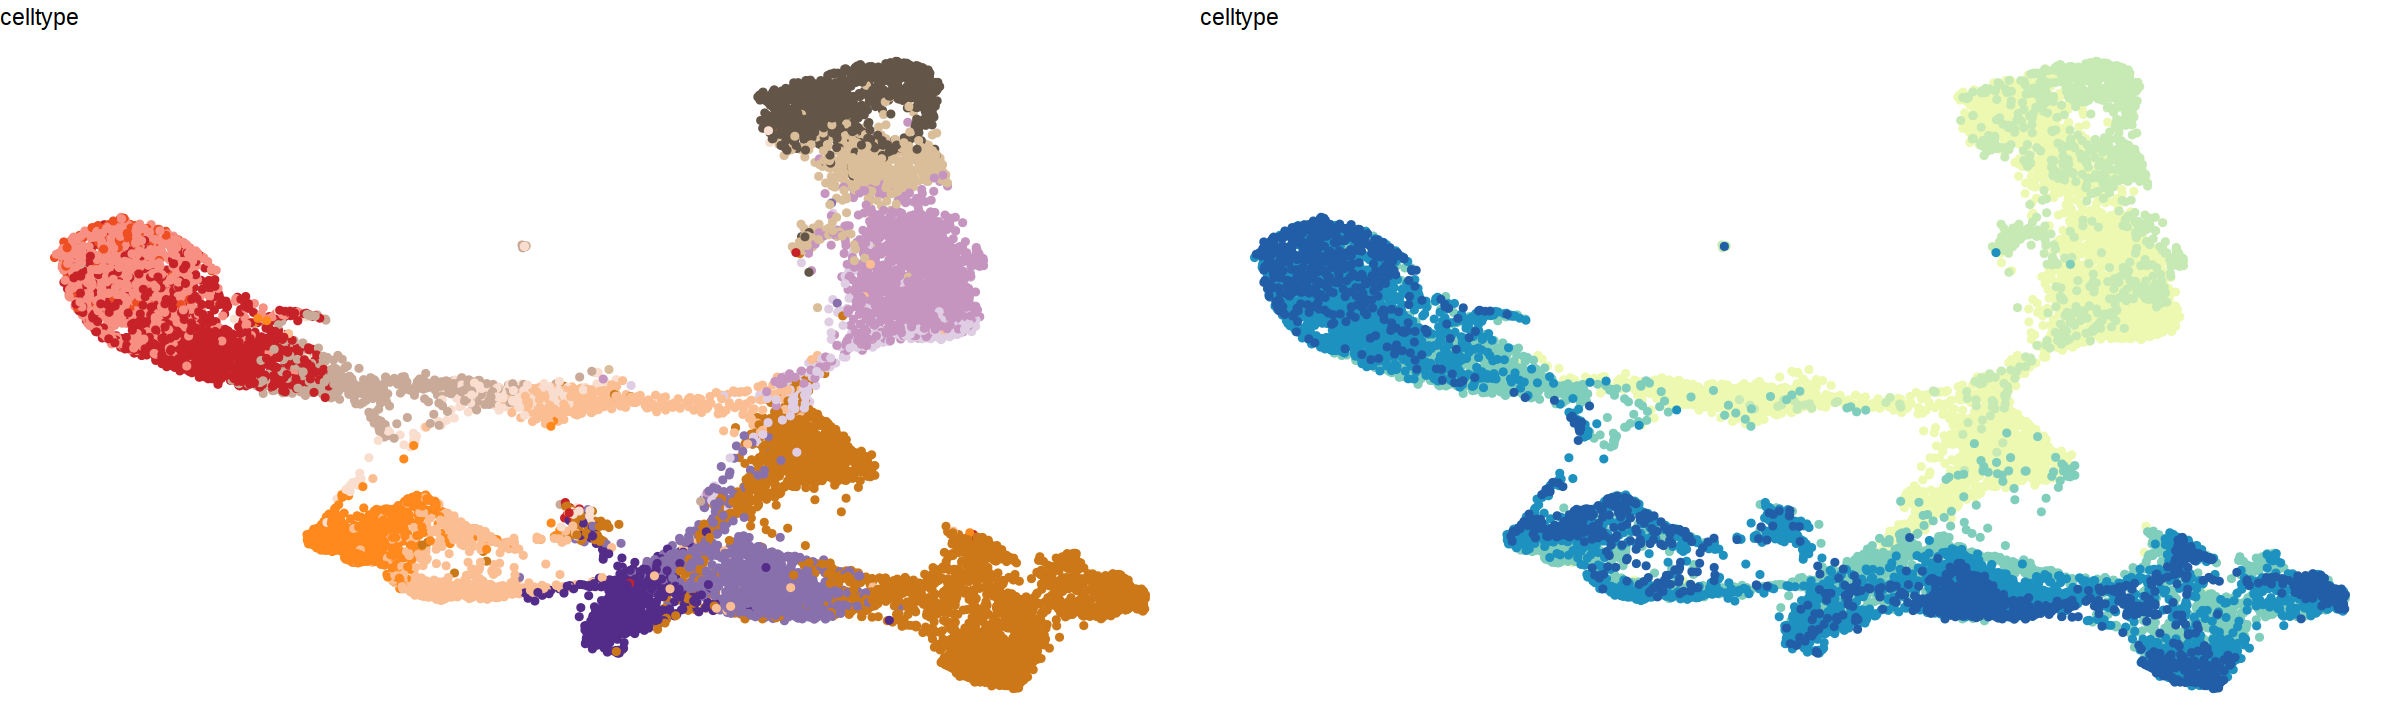

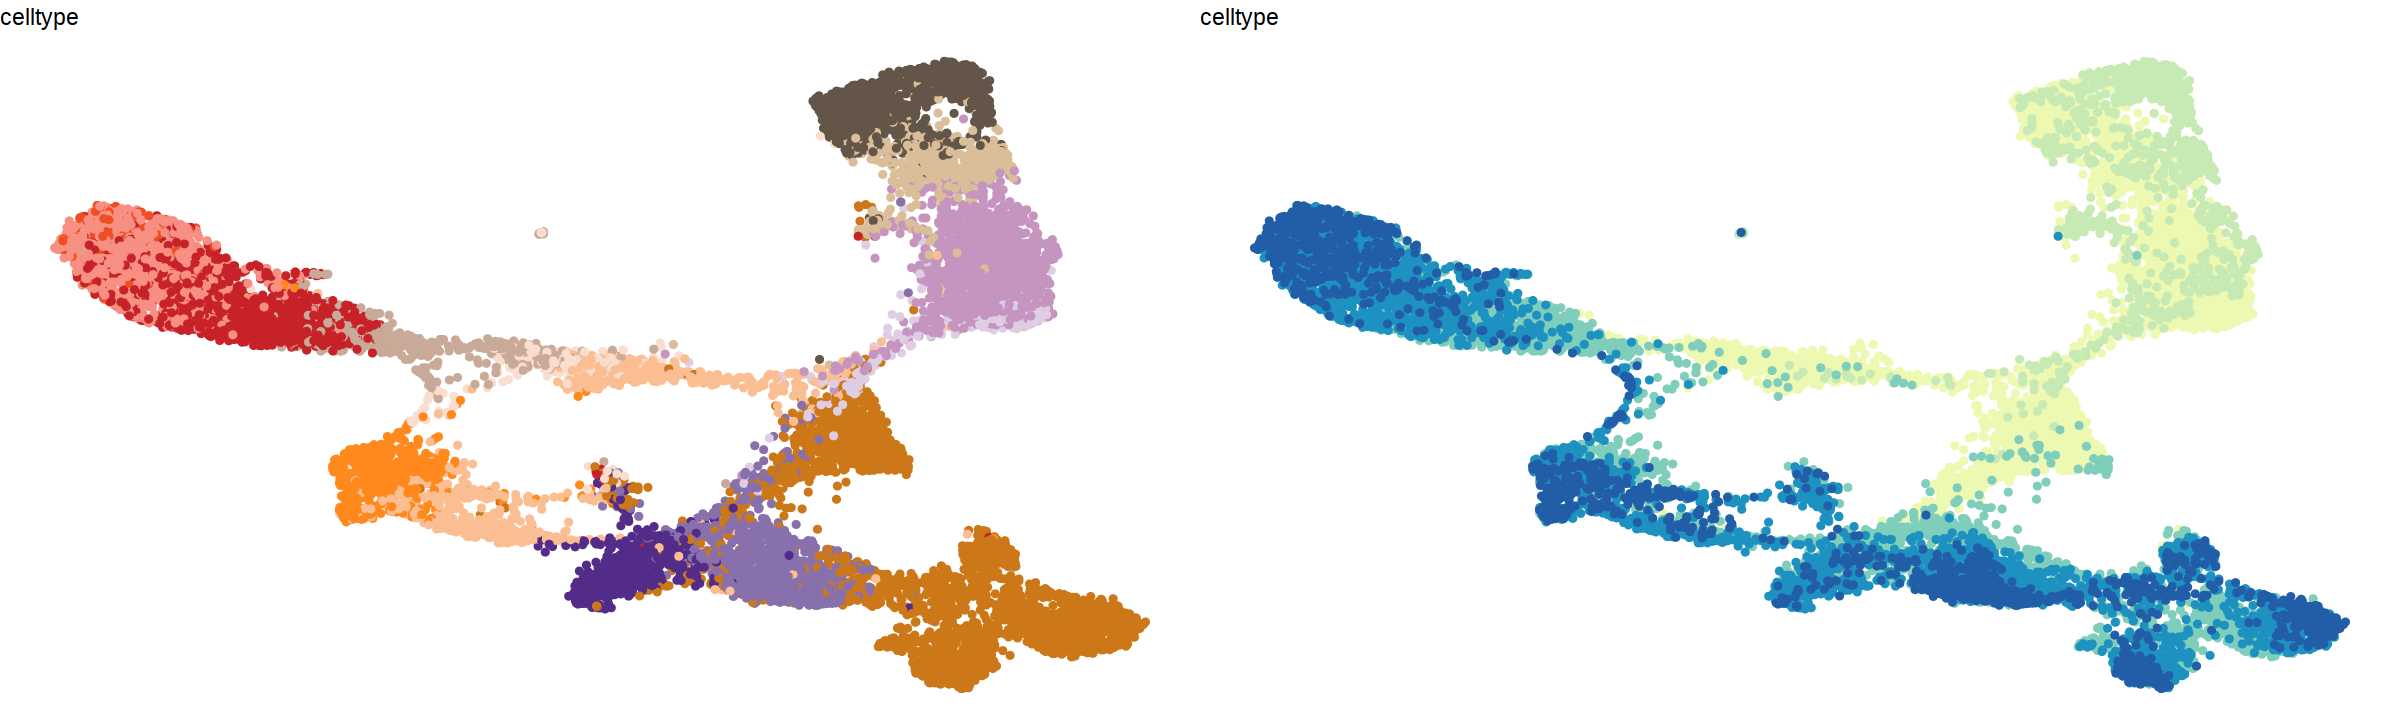

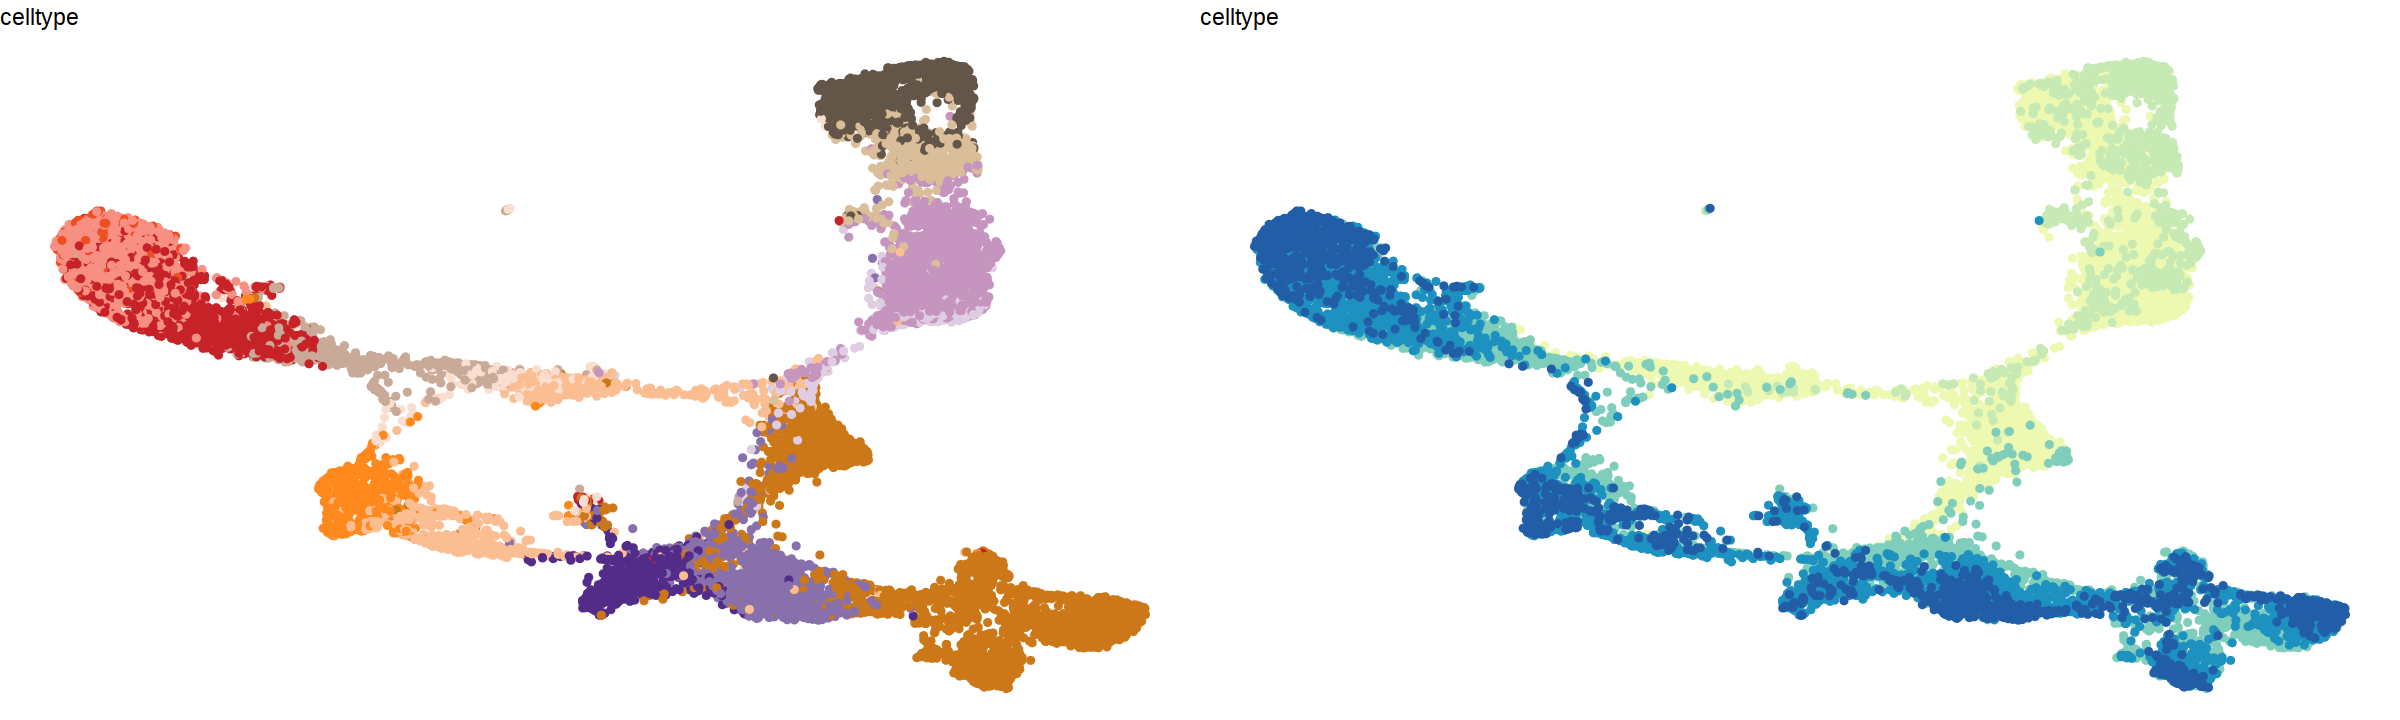

In [72]:
get_umap(n_neighbors =  30, min_dist= 0.3, plot=TRUE)
get_umap(n_neighbors =  40, min_dist= 0.3, plot=TRUE)
get_umap(n_neighbors =  30, min_dist= 0.2, plot=TRUE)

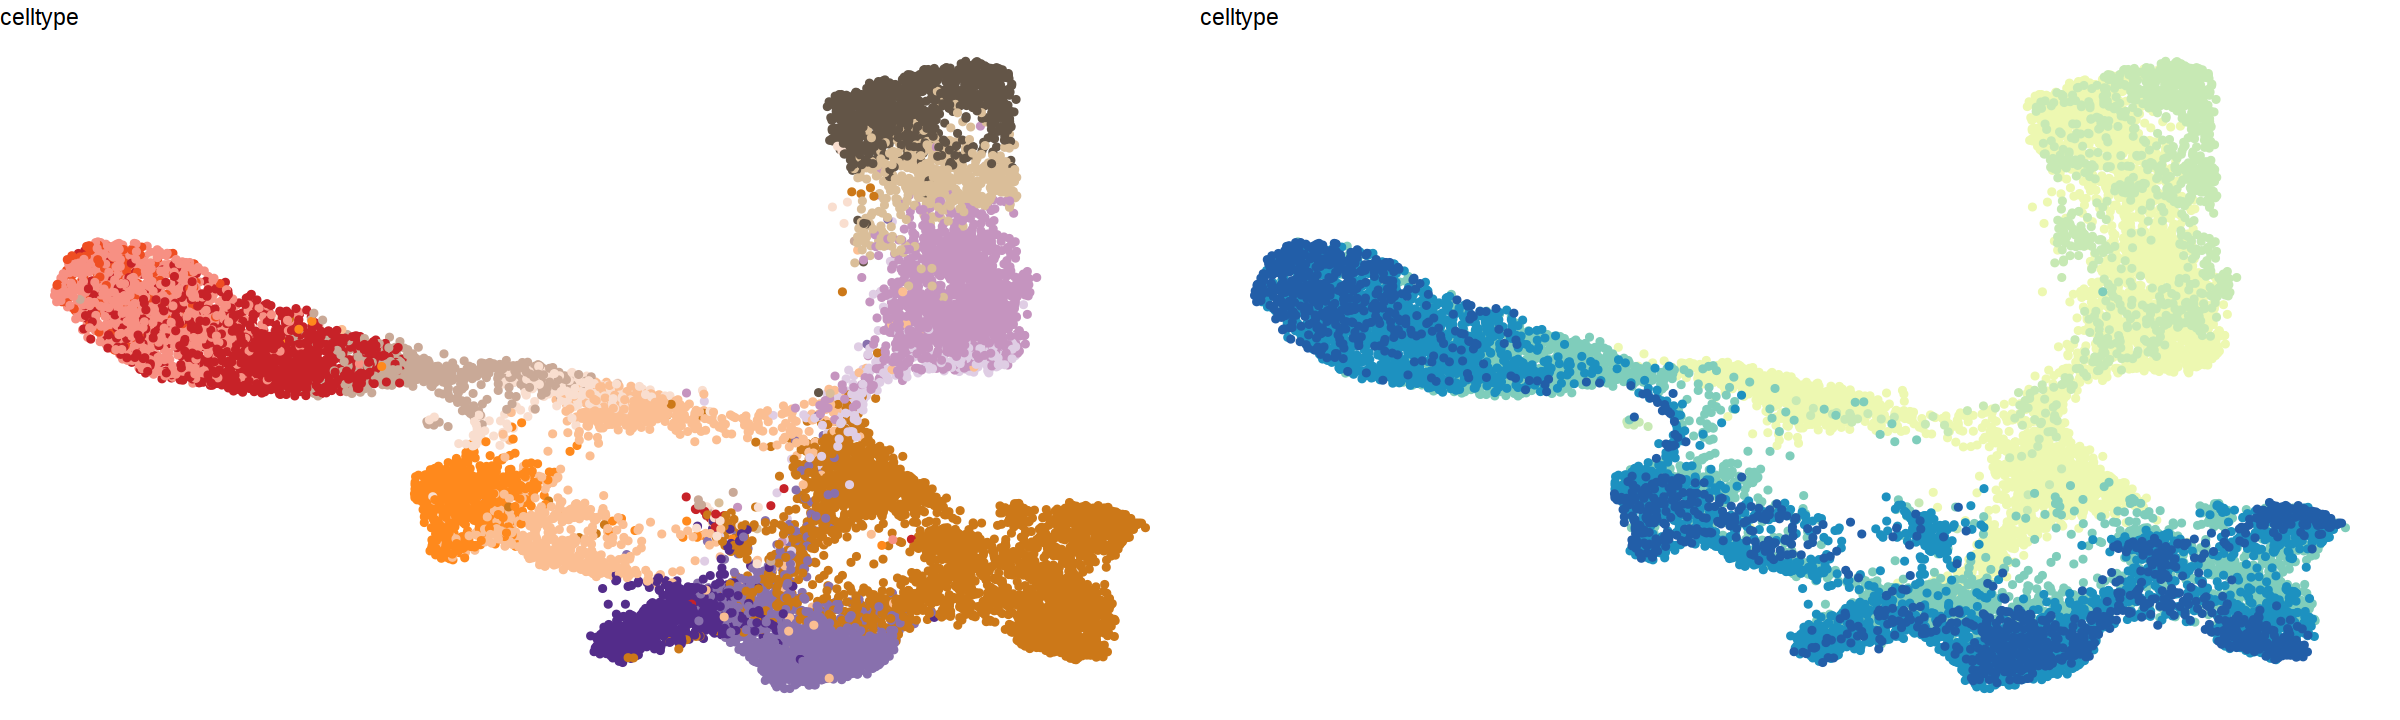

In [77]:
get_umap(n_neighbors =  200, min_dist= 0.5, plot=TRUE)

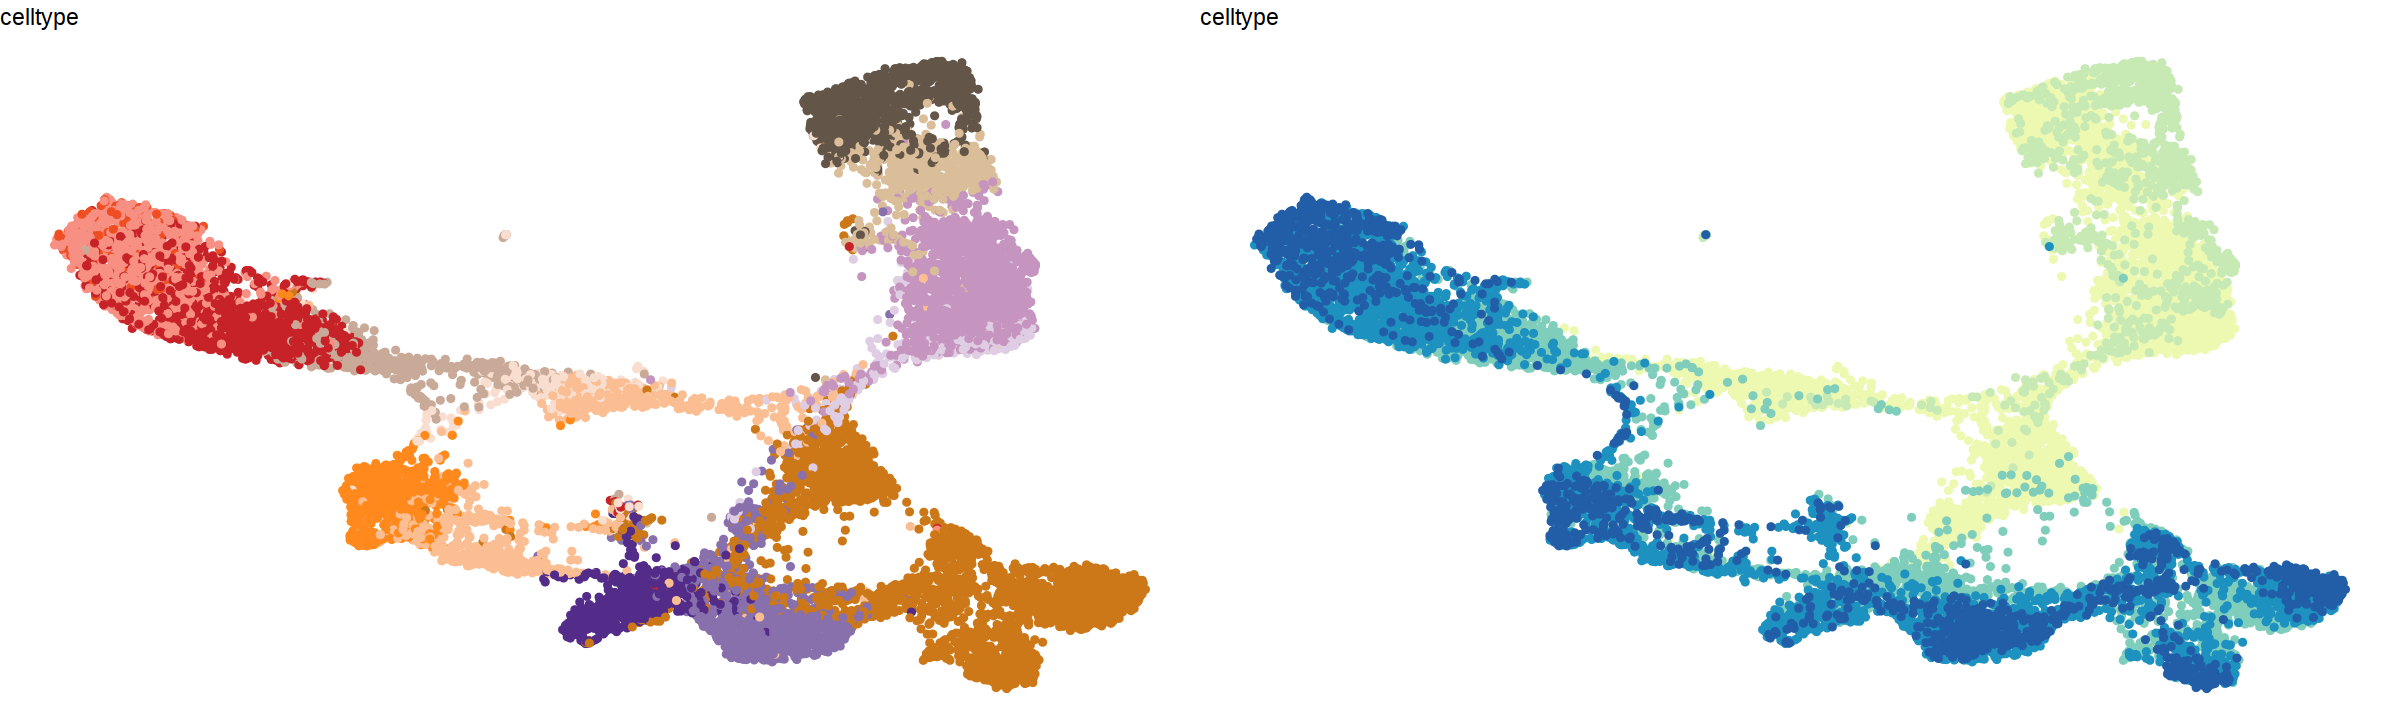

In [79]:
get_umap(n_neighbors =  40, min_dist= 0.3, plot=TRUE)

In [84]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/blood_trajectory"

In [11]:
proj <- addIterativeLSI(
    ArchRProj = proj,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI_2", 
    iterations = 2, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.4), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 30000, 
    dimsToUse = 1:args$ndims
)
LSI = getReducedDims(ArchRProj = proj, reducedDims = "IterativeLSI_2",)


Checking Inputs...

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

Filtering 1 dims correlated > 0.75 to log10(depth + 1)



ERROR: Error in get_umap(n_neighbors = 30, min_dist = 0.3, plot = TRUE): could not find function "get_umap"


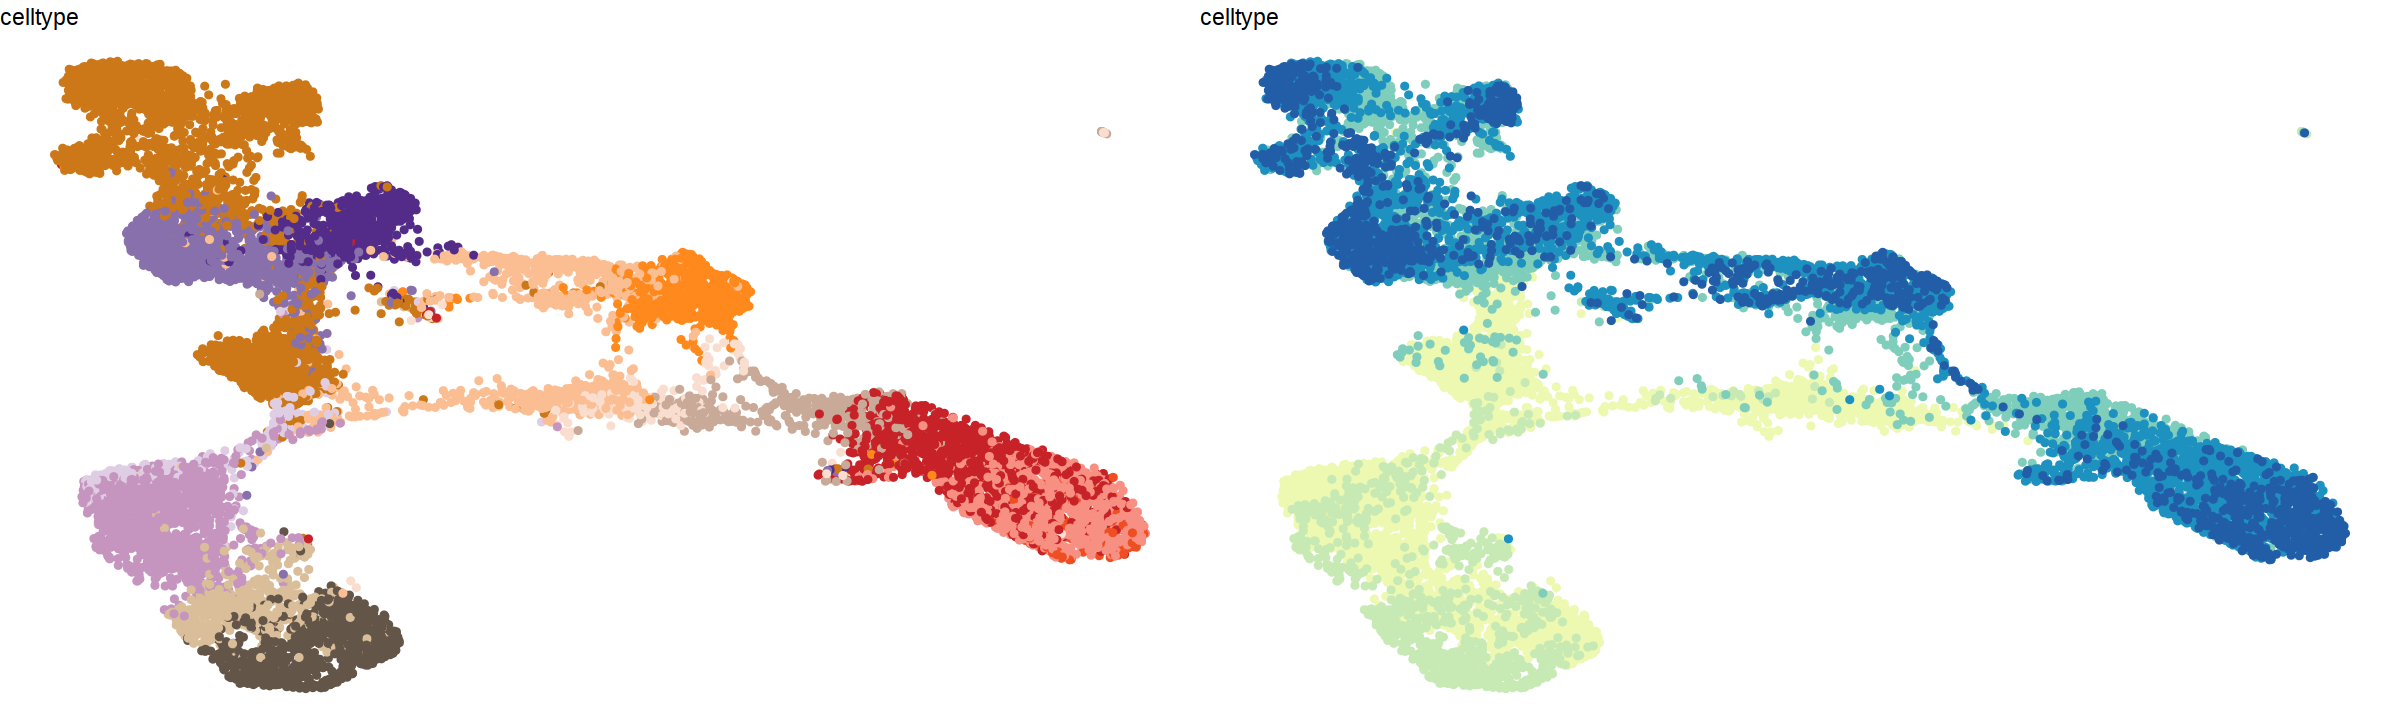

In [13]:
get_umap(n_neighbors =  30, min_dist= 0.3, plot=TRUE)

In [14]:
LSI.full = getReducedDims(ArchRProj = proj, reducedDims = "IterativeLSI_2",returnMatrix = F)

Filtering 1 dims correlated > 0.75 to log10(depth + 1)



In [15]:
features = as.data.table(LSI.full$LSIFeatures) %>%
   .[,feature:=paste0(seqnames, ':', start, '-', end)]
head(features)

seqnames,idx,start,end,rowSums,feature
<chr>,<int>,<int>,<int>,<dbl>,<chr>
chr1,7,3482876,3483476,5916,chr1:3482876-3483476
chr1,13,3670515,3671115,35116,chr1:3670515-3671115
chr1,14,3671511,3672111,50843,chr1:3671511-3672111
chr1,41,4491836,4492436,28676,chr1:4491836-4492436
chr1,42,4492444,4493044,20847,chr1:4492444-4493044
chr1,43,4493400,4494000,33319,chr1:4493400-4494000


In [16]:
fwrite(as.data.table(features, keep.rownames=T), sprintf("%s/atac_variable_features.txt.gz",args$outdir))

In [105]:
rownames(loadings) = features$feature